## Homework

> **Note**: it's very likely that in this homework your answers won't match 
> the options exactly. That's okay and expected. Select the option that's
> closest to your solution.
> If it's exactly in between two options, select the higher value.

### Dataset

In this homework, we'll build a model for classifying various hair types. 
For this, we will use the Hair Type dataset that was obtained from 
[Kaggle](https://www.kaggle.com/datasets/kavyasreeb/hair-type-dataset) 
and slightly rebuilt.

You can download the target dataset for this homework from 
[here](https://github.com/SVizor42/ML_Zoomcamp/releases/download/straight-curly-data/data.zip):

```bash
wget https://github.com/SVizor42/ML_Zoomcamp/releases/download/straight-curly-data/data.zip
unzip data.zip
```

In the lectures we saw how to use a pre-trained neural network. In the homework, we'll train a much smaller model from scratch. 

We will use PyTorch for that.

You can use Google Colab or your own computer for that.

### Data Preparation

The dataset contains around 1000 images of hairs in the separate folders 
for training and test sets. 

In [64]:
data_url = "https://github.com/SVizor42/ML_Zoomcamp/releases/download/straight-curly-data/data.zip"

In [65]:
# !wget $data_url -O "../data/HairType.zip"

In [66]:
# unzip data.zip
# !unzip ../data/HairType.zip -d ../data/HairType

### Reproducibility

Reproducibility in deep learning is a multifaceted challenge that requires attention 
to both software and hardware details. In some cases, we can't guarantee exactly the same results during the same experiment runs.

Therefore, in this homework we suggest to set the random number seed generators by:

```python
import numpy as np
import torch

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
```

Also, use PyTorch of version 2.8.0 (that's the one in Colab).|

In [67]:
import numpy as np
import torch

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### Model

For this homework we will use Convolutional Neural Network (CNN). We'll use PyTorch.

You need to develop the model with following structure:

* The shape for input should be `(3, 200, 200)` (channels first format in PyTorch)
* Next, create a convolutional layer (`nn.Conv2d`):
    * Use 32 filters (output channels)
    * Kernel size should be `(3, 3)` (that's the size of the filter)
    * Use `'relu'` as activation 
* Reduce the size of the feature map with max pooling (`nn.MaxPool2d`)
    * Set the pooling size to `(2, 2)`
* Turn the multi-dimensional result into vectors using `flatten` or `view`
* Next, add a `nn.Linear` layer with 64 neurons and `'relu'` activation
* Finally, create the `nn.Linear` layer with 1 neuron - this will be the output
    * The output layer should have an activation - use the appropriate activation for the binary classification case

As optimizer use `torch.optim.SGD` with the following parameters:

* `torch.optim.SGD(model.parameters(), lr=0.002, momentum=0.8)`

**Imports**

In [68]:
import os
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image

**Directory**

In [69]:
DATA_DIR = "../data/HairType/data"
DATA_DIR

'../data/HairType/data'

In [70]:
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TRAIN_DIR

'../data/HairType/data/train'

In [71]:
TEST_DIR = os.path.join(DATA_DIR, "test")
TEST_DIR

'../data/HairType/data/test'

**The shape for input should be `(3, 200, 200)` (channels first format in PyTorch)**

In [72]:
train_transforms = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor()
])

In [73]:
train_transforms

Compose(
    Resize(size=(200, 200), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)

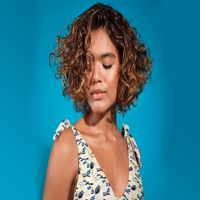

In [74]:
img = Image.open(f"{TRAIN_DIR}/curly/tp-sassy-short-curly-hairstyles-women.jpg")
img.resize((200, 200))

In [75]:
x = train_transforms(img)
x

tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.4745, 0.4745, 0.4745,  ..., 0.4471, 0.4471, 0.4471],
         [0.4784, 0.4784, 0.4745,  ..., 0.4471, 0.4471, 0.4471],
         [0.4784, 0.4784, 0.4784,  ..., 0.4471, 0.4471, 0.4471],
         ...,
         [0.6118, 0.6118, 0.6118,  ..., 0.4745, 0.4745, 0.4745],
         [0.6078, 0.6118, 0.6118,  ..., 0.4745, 0.4745, 0.4745],
         [0.6078, 0.6078, 0.6078,  ..., 0.4784, 0.4784, 0.4745]],

        [[0.6196, 0.6196, 0.6196,  ..., 0.5922, 0.5922, 0.5922],
         [0.6235, 0.6235, 0.6196,  ..., 0.5922, 0.5922, 0.5922],
         [0.6235, 0.6235, 0.6235,  ..., 0.5922, 0.5922, 0.

In [76]:
x.shape

torch.Size([3, 200, 200])

In [77]:
test_transforms = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor()
])

In [78]:
test_transforms

Compose(
    Resize(size=(200, 200), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)

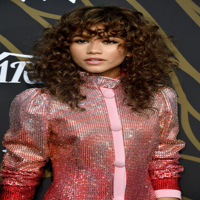

In [79]:
img = Image.open(f"{TEST_DIR}/curly/6d8acb0fe980774ea4e5631198587f45.png")
img.resize((200, 200))

In [80]:
x = train_transforms(img)
x

tensor([[[0.1255, 0.1294, 0.1294,  ..., 0.1294, 0.1333, 0.1412],
         [0.1294, 0.1294, 0.1294,  ..., 0.1333, 0.1333, 0.1412],
         [0.1333, 0.1333, 0.1373,  ..., 0.1373, 0.1373, 0.1373],
         ...,
         [0.2275, 0.2784, 0.3529,  ..., 0.1137, 0.1098, 0.1020],
         [0.2667, 0.3098, 0.3922,  ..., 0.1098, 0.1059, 0.1059],
         [0.2588, 0.2549, 0.3843,  ..., 0.1020, 0.1059, 0.1020]],

        [[0.1412, 0.1451, 0.1451,  ..., 0.1451, 0.1490, 0.1412],
         [0.1412, 0.1451, 0.1451,  ..., 0.1490, 0.1490, 0.1529],
         [0.1451, 0.1490, 0.1490,  ..., 0.1529, 0.1529, 0.1569],
         ...,
         [0.0157, 0.0275, 0.0314,  ..., 0.1137, 0.1098, 0.1059],
         [0.0196, 0.0275, 0.0392,  ..., 0.1098, 0.1059, 0.1059],
         [0.0196, 0.0235, 0.0392,  ..., 0.1020, 0.1059, 0.0980]],

        [[0.1529, 0.1569, 0.1569,  ..., 0.1569, 0.1608, 0.1608],
         [0.1569, 0.1569, 0.1569,  ..., 0.1608, 0.1608, 0.1647],
         [0.1647, 0.1647, 0.1647,  ..., 0.1647, 0.1647, 0.

In [81]:
x.shape

torch.Size([4, 200, 200])

**Next, create a convolutional layer (`nn.Conv2d`):**
 - **Use 32 filters (output channels)**
 - **Kernel size should be `(3, 3)` (that's the size of the filter)**
 - **Use `'relu'` as activation**

In [83]:
model = nn.Sequential(
    nn.Conv2d(
        in_channels=3, 
        out_channels=32, 
        kernel_size=(3, 3)
        ),
    nn.ReLU()
)


In [84]:
img = Image.open(f"{TRAIN_DIR}/curly/tp-sassy-short-curly-hairstyles-women.jpg")
img = img.resize((200, 200))

In [85]:
img_tensor = train_transforms(img)
print(img_tensor.shape)

torch.Size([3, 200, 200])


In [86]:
img_tensor = img_tensor.unsqueeze(0)
print(img_tensor.shape)

torch.Size([1, 3, 200, 200])


In [88]:
output = model(img_tensor)
print(output.shape)

torch.Size([1, 32, 198, 198])


**Reduce the size of the feature map with max pooling (`nn.MaxPool2d`)**
 - **Set the pooling size to `(2, 2)`**

In [ ]:
model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=(3,3)),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=(2,2))  # <-- reduces feature map size by 2
)

**Turn the multi-dimensional result into vectors using `flatten` or `view`**

In [ ]:
model = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=(3,3)),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=(2,2)),
    nn.Flatten()   # <-- flattens from (32, 99, 99) → 32*99*99
)

**Next, add a `nn.Linear` layer with 64 neurons and `'relu'` activation**

In [89]:
model = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=(3,3)),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=(2,2)),
    nn.Flatten(),
    
    nn.Linear(32 * 99 * 99, 64),  # <-- 64 neurons
    nn.ReLU()                     # <-- activation
)

**Finally, create the `nn.Linear` layer with 1 neuron - this will be the output**
 - **The output layer should have an activation - use the appropriate activation for the binary classification case**

In [90]:
model = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=(3,3)),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=(2,2)),
    nn.Flatten(),
    nn.Linear(32 * 99 * 99, 64),
    nn.ReLU(),
    
    nn.Linear(64, 1)  # <-- final output layer
)

**Final model explained**

In [96]:
model = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=(3,3)),  # 32 filters, 3×3 kernel
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=(2,2)),      # (2,2) pooling → reduces spatial size
    nn.Flatten(),                         # flatten (32, 99, 99) → 313,632

    nn.Linear(32 * 99 * 99, 64),           # fully connected layer with 64 neurons
    nn.ReLU(),                             # activation

    nn.Linear(64, 1)                       # final binary logit output
)

**As optimizer use `torch.optim.SGD` with the following parameters:**
 - **`torch.optim.SGD(model.parameters(), lr=0.002, momentum=0.8)`**

In [98]:
optimizer = torch.optim.SGD(
    model.parameters(), 
    lr=0.002, 
    momentum=0.8
)

### Question 1

Which loss function you will use?

* `nn.MSELoss()`
* **`nn.BCEWithLogitsLoss()`**
* `nn.CrossEntropyLoss()`
* `nn.CosineEmbeddingLoss()`

(Multiple answered can be correct, so pick any)

In [99]:
# Define the loss function for binary classification
criterion = nn.BCEWithLogitsLoss()

### Question 2

What's the total number of parameters of the model? You can use `torchsummary` or count manually. 

In PyTorch, you can find the total number of parameters using:

```python
# Option 1: Using torchsummary (install with: pip install torchsummary)
from torchsummary import summary
summary(model, input_size=(3, 200, 200))

# Option 2: Manual counting
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")
```

* 896 
* 11214912
* 15896912
* **20073473**

In [102]:
from torchinfo import summary
summary(model, input_size=(1, 3, 200, 200))  # include batch size

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 1]                    --
├─Conv2d: 1-1                            [1, 32, 198, 198]         896
├─ReLU: 1-2                              [1, 32, 198, 198]         --
├─MaxPool2d: 1-3                         [1, 32, 99, 99]           --
├─Flatten: 1-4                           [1, 313632]               --
├─Linear: 1-5                            [1, 64]                   20,072,512
├─ReLU: 1-6                              [1, 64]                   --
├─Linear: 1-7                            [1, 1]                    65
Total params: 20,073,473
Trainable params: 20,073,473
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 55.20
Input size (MB): 0.48
Forward/backward pass size (MB): 10.04
Params size (MB): 80.29
Estimated Total Size (MB): 90.81

In [101]:
# Option 1: Using torchsummary (install with: pip install torchsummary)
from torchsummary import summary
summary(model, input_size=(3, 200, 200))

Layer (type:depth-idx)                   Param #
├─Conv2d: 1-1                            896
├─ReLU: 1-2                              --
├─MaxPool2d: 1-3                         --
├─Flatten: 1-4                           --
├─Linear: 1-5                            20,072,512
├─ReLU: 1-6                              --
├─Linear: 1-7                            65
Total params: 20,073,473
Trainable params: 20,073,473
Non-trainable params: 0


Layer (type:depth-idx)                   Param #
├─Conv2d: 1-1                            896
├─ReLU: 1-2                              --
├─MaxPool2d: 1-3                         --
├─Flatten: 1-4                           --
├─Linear: 1-5                            20,072,512
├─ReLU: 1-6                              --
├─Linear: 1-7                            65
Total params: 20,073,473
Trainable params: 20,073,473
Non-trainable params: 0

In [103]:
# Option 2: Manual counting
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 20073473


### Generators and Training

For the next two questions, use the following transformation for both train and test sets:

```python
train_transforms = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ) # ImageNet normalization
])
```

* We don't need to do any additional pre-processing for the images.
* Use `batch_size=20`
* Use `shuffle=True` for both training, but `False` for test. 

Now fit the model.

You can use this code:

```python
num_epochs = 10
history = {'acc': [], 'loss': [], 'val_acc': [], 'val_loss': []}

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        labels = labels.float().unsqueeze(1) # Ensure labels are float and have shape (batch_size, 1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        # For binary classification with BCEWithLogitsLoss, apply sigmoid to outputs before thresholding for accuracy
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct_train / total_train
    history['loss'].append(epoch_loss)
    history['acc'].append(epoch_acc)

    model.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for images, labels in validation_loader:
            images, labels = images.to(device), labels.to(device)
            labels = labels.float().unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_epoch_loss = val_running_loss / len(validation_dataset)
    val_epoch_acc = correct_val / total_val
    history['val_loss'].append(val_epoch_loss)
    history['val_acc'].append(val_epoch_acc)

    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}, "
          f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.4f}"))
```

**Create the transformators**

In [104]:
train_transforms = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ) # ImageNet normalization
])

In [106]:
test_transforms = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

**Load the datasets using the ImageFolder**

In [107]:
from torchvision.datasets import ImageFolder

In [108]:
train_dataset = ImageFolder(
    root=TRAIN_DIR,
    transform=train_transforms
)

In [109]:
validation_dataset = ImageFolder(
    root=TEST_DIR,
    transform=test_transforms
)

**Create the DataLoaders**

In [110]:
from torch.utils.data import DataLoader

In [111]:
train_loader = DataLoader(
    train_dataset,
    batch_size=20,
    shuffle=True
)

In [112]:
validation_loader = DataLoader(
    validation_dataset,
    batch_size=20,
    shuffle=False
)

**Device, loss function, optimizer**

In [114]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (3): Flatten(start_dim=1, end_dim=-1)
  (4): Linear(in_features=313632, out_features=64, bias=True)
  (5): ReLU()
  (6): Linear(in_features=64, out_features=1, bias=True)
)

In [115]:
criterion = nn.BCEWithLogitsLoss()

In [116]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.002, momentum=0.8)

**Traing loop**

In [118]:
num_epochs = 10
history = {'acc': [], 'loss': [], 'val_acc': [], 'val_loss': []}

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        labels = labels.float().unsqueeze(1) # Ensure labels are float and have shape (batch_size, 1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        # For binary classification with BCEWithLogitsLoss, apply sigmoid to outputs before thresholding for accuracy
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct_train / total_train
    history['loss'].append(epoch_loss)
    history['acc'].append(epoch_acc)

    model.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for images, labels in validation_loader:
            images, labels = images.to(device), labels.to(device)
            labels = labels.float().unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_epoch_loss = val_running_loss / len(validation_dataset)
    val_epoch_acc = correct_val / total_val
    history['val_loss'].append(val_epoch_loss)
    history['val_acc'].append(val_epoch_acc)

    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}, "
          f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.4f}")

Epoch 1/10, Loss: 0.6181, Acc: 0.6637, Val Loss: 0.6204, Val Acc: 0.6418
Epoch 2/10, Loss: 0.5108, Acc: 0.7550, Val Loss: 0.5700, Val Acc: 0.7065
Epoch 3/10, Loss: 0.4977, Acc: 0.7438, Val Loss: 0.6316, Val Acc: 0.6716
Epoch 4/10, Loss: 0.3853, Acc: 0.8300, Val Loss: 0.7089, Val Acc: 0.6567
Epoch 5/10, Loss: 0.3082, Acc: 0.8700, Val Loss: 0.6569, Val Acc: 0.7065
Epoch 6/10, Loss: 0.2572, Acc: 0.9025, Val Loss: 0.5448, Val Acc: 0.7363
Epoch 7/10, Loss: 0.1634, Acc: 0.9450, Val Loss: 0.7716, Val Acc: 0.7065
Epoch 8/10, Loss: 0.1394, Acc: 0.9487, Val Loss: 1.3023, Val Acc: 0.6020
Epoch 9/10, Loss: 0.1472, Acc: 0.9425, Val Loss: 0.7422, Val Acc: 0.7612
Epoch 10/10, Loss: 0.0896, Acc: 0.9762, Val Loss: 0.7519, Val Acc: 0.7313


### Question 3

What is the median of training accuracy for all the epochs for this model?

* 0.05
* 0.12
* 0.40
* **0.84**

In [121]:
history['acc']

[0.66375, 0.755, 0.74375, 0.83, 0.87, 0.9025, 0.945, 0.94875, 0.9425, 0.97625]

In [124]:
median_acc = np.median(history['acc'])
print(median_acc)

0.88625


In [125]:
accs = history['acc']
accs_sorted = sorted(accs)
mid = len(accs_sorted) // 2
median = (accs_sorted[mid - 1] + accs_sorted[mid]) / 2
print(median)

0.88625


### Question 4

What is the standard deviation of training loss for all the epochs for this model?

* 0.007
* 0.078
* **0.171**
* 1.710

In [131]:
history['loss']

[0.6180925458669663,
 0.5107604041695595,
 0.4976906418800354,
 0.3853248193860054,
 0.3081502918154001,
 0.2572383340448141,
 0.1634030554443598,
 0.13936798116192223,
 0.1472473149187863,
 0.0896298654610291]

In [132]:
np.std(history['loss']).round(3)

np.float64(0.175)

### Data Augmentation

For the next two questions, we'll generate more data using data augmentations. 

Add the following augmentations to your training data generator:

```python
transforms.RandomRotation(50),
transforms.RandomResizedCrop(200, scale=(0.9, 1.0), ratio=(0.9, 1.1)),
transforms.RandomHorizontalFlip(),
```

**Update train_transforms**

In [133]:
train_transforms = transforms.Compose([
    transforms.RandomRotation(50),                      # rotate images up to ±50 degrees
    transforms.RandomResizedCrop(200, scale=(0.9, 1.0), ratio=(0.9, 1.1)),  # random crop & resize
    transforms.RandomHorizontalFlip(),                  # randomly flip horizontally
    transforms.Resize((200, 200)),                      # ensure final size
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

**test_transforms will remain the same**

**Re-create the training dataset & loader**

In [134]:
train_dataset = ImageFolder(root=TRAIN_DIR, transform=train_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=20,
    shuffle=True
)

### Question 5 

Let's train our model for 10 more epochs using the same code as previously.

> **Note:** make sure you don't re-create the model.
> we want to continue training the model we already started training.

What is the mean of test loss for all the epochs for the model trained with augmentations?

* 0.008
* **0.08**
* 0.88
* 8.88

**Make sure the model is the same**

In [135]:
model.train()

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (3): Flatten(start_dim=1, end_dim=-1)
  (4): Linear(in_features=313632, out_features=64, bias=True)
  (5): ReLU()
  (6): Linear(in_features=64, out_features=1, bias=True)
)

**Continue training for 10 more epochs**

In [136]:
num_epochs_aug = 10
history_aug = {'acc': [], 'loss': [], 'val_acc': [], 'val_loss': []}

for epoch in range(num_epochs_aug):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        labels = labels.float().unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct_train / total_train

    history_aug['loss'].append(epoch_loss)
    history_aug['acc'].append(epoch_acc)
    
    model.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in validation_loader:
            images, labels = images.to(device), labels.to(device)
            labels = labels.float().unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_epoch_loss = val_running_loss / len(validation_dataset)
    val_epoch_acc = correct_val / total_val

    history_aug['val_loss'].append(val_epoch_loss)
    history_aug['val_acc'].append(val_epoch_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs_aug}, "
        f"Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}, "
        f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.4f}"
    )

Epoch 1/10, Loss: 0.6770, Acc: 0.6613, Val Loss: 0.5160, Val Acc: 0.7512
Epoch 2/10, Loss: 0.5181, Acc: 0.7300, Val Loss: 0.5323, Val Acc: 0.7264
Epoch 3/10, Loss: 0.5387, Acc: 0.7000, Val Loss: 0.5200, Val Acc: 0.7612
Epoch 4/10, Loss: 0.5254, Acc: 0.7462, Val Loss: 0.5188, Val Acc: 0.6915
Epoch 5/10, Loss: 0.4811, Acc: 0.7662, Val Loss: 0.4951, Val Acc: 0.7214
Epoch 6/10, Loss: 0.4611, Acc: 0.7688, Val Loss: 0.5245, Val Acc: 0.7164
Epoch 7/10, Loss: 0.4578, Acc: 0.7837, Val Loss: 0.5019, Val Acc: 0.7214
Epoch 8/10, Loss: 0.4590, Acc: 0.7775, Val Loss: 0.5040, Val Acc: 0.7264
Epoch 9/10, Loss: 0.4378, Acc: 0.7900, Val Loss: 0.4688, Val Acc: 0.7512
Epoch 10/10, Loss: 0.4218, Acc: 0.8050, Val Loss: 0.4564, Val Acc: 0.8010


In [138]:
history_aug['val_loss']

[0.5159961757671774,
 0.5323152528769934,
 0.520011277934212,
 0.5187507354798009,
 0.4950755100641678,
 0.5244896429688183,
 0.5019138701519563,
 0.5040457588226641,
 0.4687990463195156,
 0.45637835999626425]

In [140]:
mean_val_loss = np.mean(history_aug['val_loss'])
mean_val_loss.round(3)

np.float64(0.504)

### Question 6

What's the average of test accuracy for the last 5 epochs (from 6 to 10)
for the model trained with augmentations?

* 0.08
* 0.28
* **0.68**
* 0.98

In [141]:
history_aug['val_acc']

[0.7512437810945274,
 0.7263681592039801,
 0.7611940298507462,
 0.6915422885572139,
 0.7213930348258707,
 0.7164179104477612,
 0.7213930348258707,
 0.7263681592039801,
 0.7512437810945274,
 0.8009950248756219]

In [ ]:
last_5_val_acc = history_aug['val_acc'][-5:]
last_5_val_acc

[0.7164179104477612,
 0.7213930348258707,
 0.7263681592039801,
 0.7512437810945274,
 0.8009950248756219]

In [144]:
avg_last_5_val_acc = np.mean(last_5_val_acc)
avg_last_5_val_acc.round(3)

np.float64(0.743)

## Submit the results

* Submit your results here: https://courses.datatalks.club/ml-zoomcamp-2025/homework/hw08
* If your answer doesn't match options exactly, select the closest one. If the answer is exactly in between two options, select the higher value.

# Testing the code using random images

**Load the image**

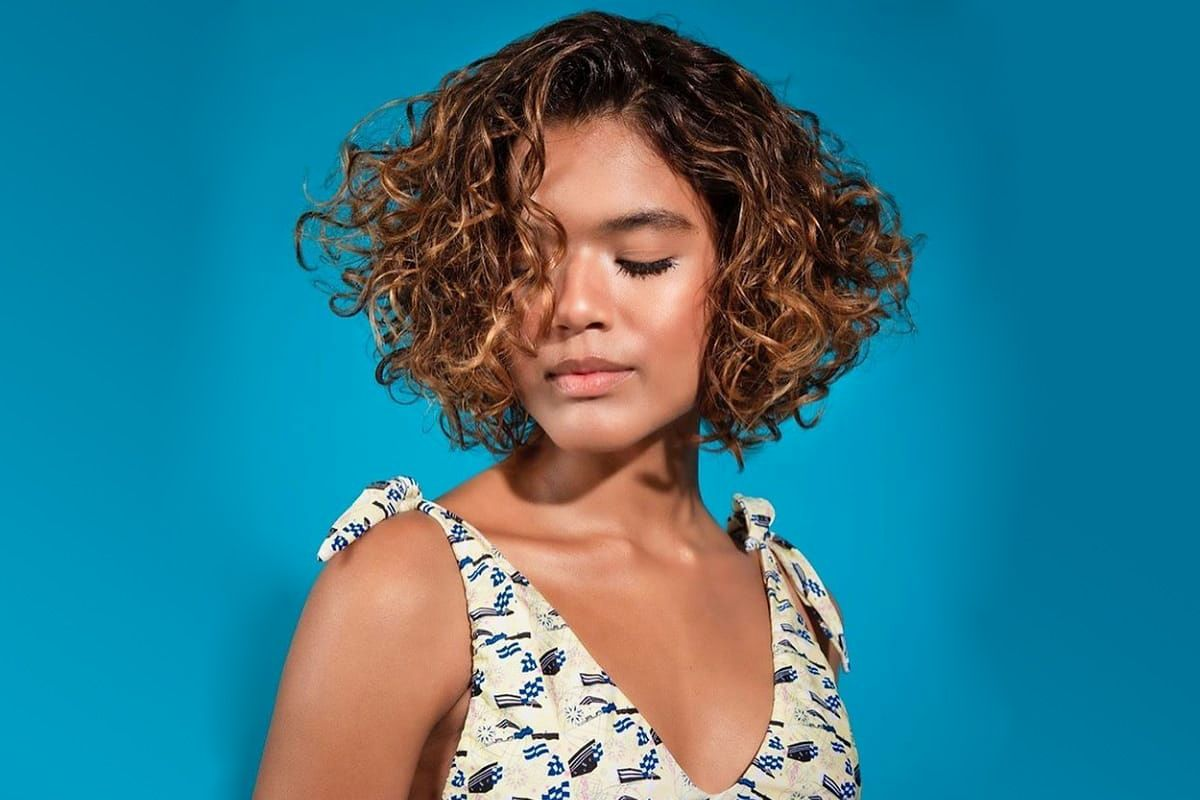

In [ ]:
img = Image.open(f"{TRAIN_DIR}/curly/tp-sassy-short-curly-hairstyles-women.jpg").convert("RGB")
img

# Got 9.81% accuracy on this image (very low confidence)

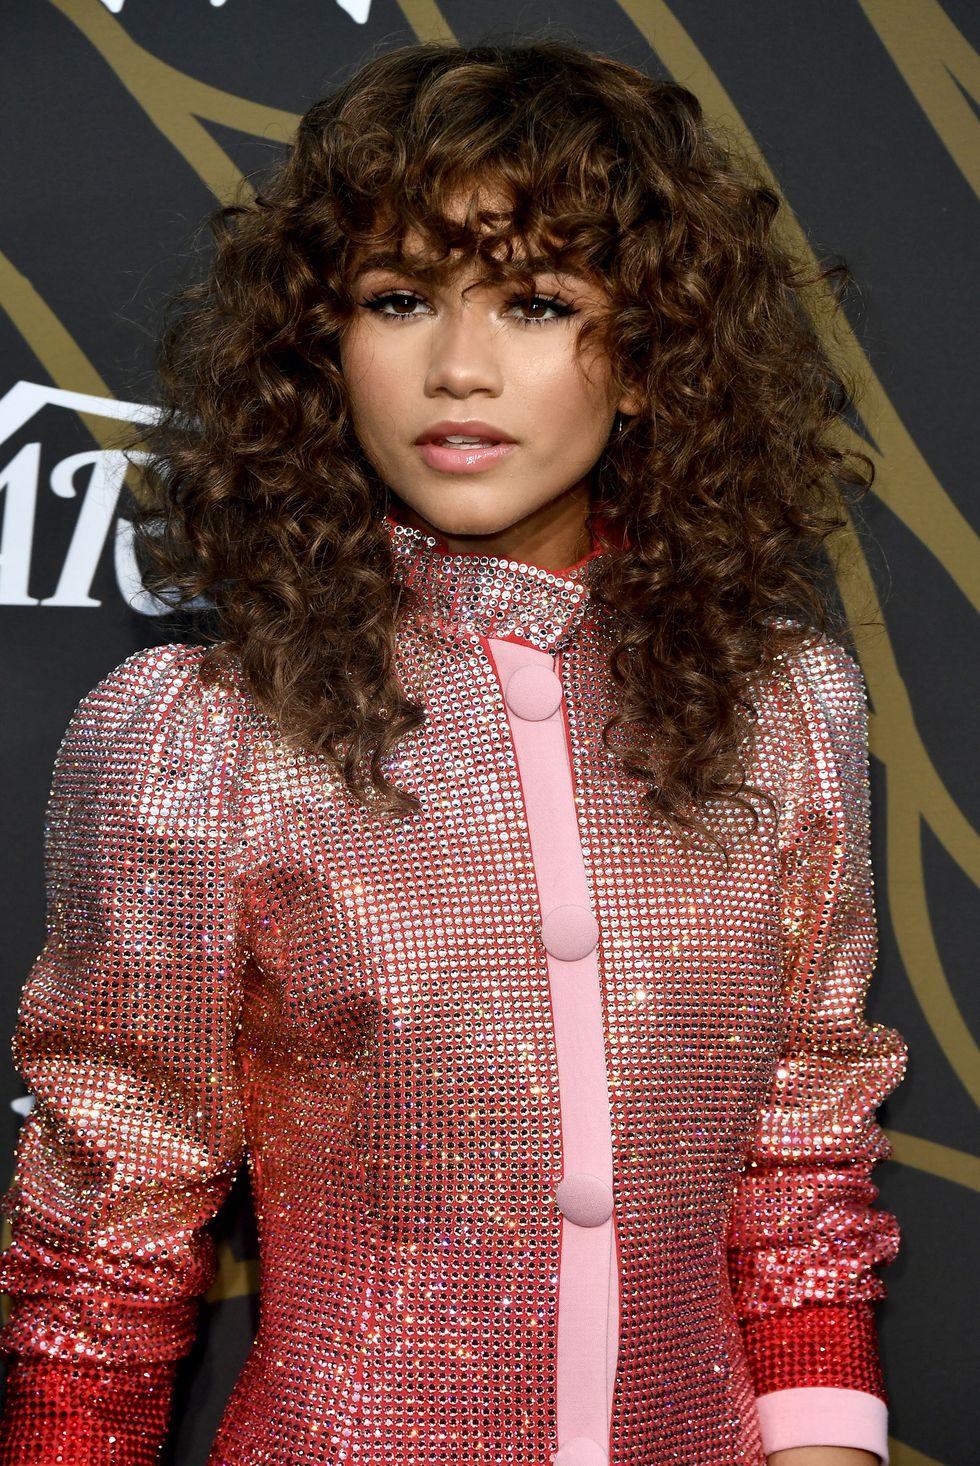

In [153]:
img = Image.open(f"{TEST_DIR}/curly/6d8acb0fe980774ea4e5631198587f45.png").convert("RGB")
img

**Apply the same transformations used  for training the model**

In [154]:
transform = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

x = transform(img)  # shape: [3, 200, 200]
x = x.unsqueeze(0)  # add batch dimension → [1, 3, 200, 200]


In [155]:
x.shape

torch.Size([1, 3, 200, 200])

In [156]:
x

tensor([[[[-1.5699, -1.5528, -1.5528,  ..., -1.5528, -1.5357, -1.5014],
          [-1.5528, -1.5528, -1.5528,  ..., -1.5357, -1.5357, -1.5014],
          [-1.5357, -1.5357, -1.5185,  ..., -1.5185, -1.5185, -1.5185],
          ...,
          [-1.1247, -0.9020, -0.5767,  ..., -1.6213, -1.6384, -1.6727],
          [-0.9534, -0.7650, -0.4054,  ..., -1.6384, -1.6555, -1.6555],
          [-0.9877, -1.0048, -0.4397,  ..., -1.6727, -1.6555, -1.6727]],

         [[-1.4055, -1.3880, -1.3880,  ..., -1.3880, -1.3704, -1.4055],
          [-1.4055, -1.3880, -1.3880,  ..., -1.3704, -1.3704, -1.3529],
          [-1.3880, -1.3704, -1.3704,  ..., -1.3529, -1.3529, -1.3354],
          ...,
          [-1.9657, -1.9132, -1.8957,  ..., -1.5280, -1.5455, -1.5630],
          [-1.9482, -1.9132, -1.8606,  ..., -1.5455, -1.5630, -1.5630],
          [-1.9482, -1.9307, -1.8606,  ..., -1.5805, -1.5630, -1.5980]],

         [[-1.1247, -1.1073, -1.1073,  ..., -1.1073, -1.0898, -1.0898],
          [-1.1073, -1.1073, -

**Move the tensore to the device**

In [157]:
device = "cuda" if torch.cuda.is_available() else "cpu"
x = x.to(device)
model.to(device)
model.eval()

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (3): Flatten(start_dim=1, end_dim=-1)
  (4): Linear(in_features=313632, out_features=64, bias=True)
  (5): ReLU()
  (6): Linear(in_features=64, out_features=1, bias=True)
)

**Run the model and geneate the probability**

In [158]:
with torch.no_grad():
    output = model(x)
    prob = torch.sigmoid(output)

print(prob.item())

0.478951096534729


In [159]:
print(f"Probability of positive class: {prob.item()*100:.2f}%")

Probability of positive class: 47.90%
